# Sumativa 3 — Modelamiento Predictivo Integrado
**MCDI501 · Grupo 4 · Bank Marketing UCI**

Evaluación Sumativa 3 (Fase 4: Presentación y comunicación). Todas las decisiones metodológicas se fundamentan explícitamente en los resultados de S1 (análisis exploratorio e inferencial) y S2 (validación mediante remuestreo y simulación), evidenciando la progresión S1 → S2 → S3.

## §0 — Configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

# Deteccion dinamica de la raiz del proyecto
raiz = Path().resolve()
for _ in range(6):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent
RUTA_CSV = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'

df_raw = pd.read_csv(RUTA_CSV, sep=';')
df_raw['y_bin'] = (df_raw['y'] == 'yes').astype(int)
print(f'Dataset cargado: {df_raw.shape}')
print(f'Tasa de suscripcion: {df_raw["y_bin"].mean():.4f} '
      f'({df_raw["y_bin"].sum():,} yes / {(df_raw["y_bin"]==0).sum():,} no)')
print(f'Columnas: {list(df_raw.columns)}')

Dataset cargado: (41188, 22)
Tasa de suscripcion: 0.1127 (4,640 yes / 36,548 no)
Columnas: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'y_bin']


## §1 — Manejo inteligente de datos faltantes

### 1.1 Referencia al analisis de S1

El dataset Bank Marketing UCI **no contiene valores NaN reales** (confirmado en S1). Los datos faltantes se codifican como la cadena `'unknown'` en variables categoricas, y como el valor centinela `999` en la variable numerica `pdays` (indica que el cliente no fue contactado en campanas anteriores).

**Patron de faltantes identificado en S1:**

| Variable | N unknowns | % | Tipo | Patron probable |
|---|---|---|---|---|
| `default` | 8.597 | 20.9 % | Categorica | MAR — clientes con credito en mora pueden negarse a responder |
| `education` | 1.731 | 4.2 % | Categorica | MAR — correlaciona con `job` y `age` |
| `housing` | 990 | 2.4 % | Categorica | MAR — relacionada con `loan` |
| `loan` | 990 | 2.4 % | Categorica | MAR — relacionada con `housing` |
| `job` | 330 | 0.8 % | Categorica | MAR — correlaciona con `education` |
| `marital` | 80 | 0.2 % | Categorica | MCAR — porcentaje marginal |
| `pdays` (= 999) | 39.673 | 96.3 % | Numerica centinela | No es faltante real: indica ausencia de contacto previo |

**Decision sobre `pdays`:** recodificado a variable binaria `contactado_previo` (1 si pdays != 999), tal como se hizo en la Formativa 2. No se imputa porque 999 no es un valor faltante sino una categoria operacional del dataset.

**Variables seleccionadas como features (S1+S2):** `euribor3m`, `poutcome_enc`, `previous`, `age`, `contactado_previo` — ninguna de ellas presenta unknowns. Las variables con unknowns (`default`, `education`, `housing`, `loan`, `job`, `marital`) no forman parte del espacio de features validado, pero el tamano muestral resultante de cada estrategia de imputacion **si afecta** el entrenamiento del modelo final.

In [2]:
# Reproducir hallazgos de S1
print('=== Valores NaN reales ===')
nans = df_raw.isnull().sum()
print(nans[nans > 0].to_string() if nans.any() else 'Ninguno')

print('\n=== Frecuencia de unknown por variable categorica ===')
cat_cols = df_raw.select_dtypes(include='object').columns.drop('y')
unk = {c: (df_raw[c] == 'unknown').sum() for c in cat_cols if (df_raw[c] == 'unknown').any()}
for col, n in sorted(unk.items(), key=lambda x: -x[1]):
    print(f'  {col:20s}: {n:5,} ({n/len(df_raw)*100:.1f}%)')

n_con_unknown = (df_raw[list(unk.keys())] == 'unknown').any(axis=1).sum()
print(f'\nObservaciones con al menos un unknown: {n_con_unknown:,} '
      f'({n_con_unknown/len(df_raw)*100:.1f}%)')

=== Valores NaN reales ===
Ninguno

=== Frecuencia de unknown por variable categorica ===
  default             : 8,597 (20.9%)
  education           : 1,731 (4.2%)
  housing             :   990 (2.4%)
  loan                :   990 (2.4%)
  job                 :   330 (0.8%)
  marital             :    80 (0.2%)

Observaciones con al menos un unknown: 10,700 (26.0%)


### 1.2 Imputacion mediante regresion

Para las variables categoricas con unknowns, se utiliza **regresion logistica multinomial** (equivalente a la regresion lineal para variables continuas, pero adaptada a variables categoricas) con 3 a 5 predictores seleccionados desde la matriz de correlaciones de S1 y validados en S2.

**Estrategia de predictores por variable:**

| Variable a imputar | Predictores usados | Justificacion (S1/S2) |
|---|---|---|
| `job` | `age`, `education`, `marital` | Correlacion con edad y nivel educativo (S1) |
| `education` | `job`, `age`, `marital` | Alta dependencia con ocupacion (S1) |
| `marital` | `age`, `education`, `job` | Correlacion con edad (S1) |
| `housing` | `loan`, `job`, `age`, `marital` | Asociacion entre productos financieros (S1) |
| `loan` | `housing`, `job`, `age`, `marital` | Idem housing |
| `default` | `job`, `age`, `housing`, `loan`, `education` | Variable con mayor proporcion de unknowns (20.9 %) |

> **Nota:** `default` presenta la mayor proporcion de unknowns (20.9 %). Dado que este patron es probablemente MAR (Missing At Random — los clientes con historial de mora podrian rehusarse a declararlo), la imputacion por regresion es metodologicamente superior a la simple.

In [3]:
# Variables con unknowns y sus predictores
VARS_CON_UNKNOWNS = ['job', 'education', 'marital', 'housing', 'loan', 'default']
PREDICTORES_POR_VAR = {
    'job':       ['age', 'education', 'marital'],
    'education': ['job', 'age', 'marital'],
    'marital':   ['age', 'education', 'job'],
    # housing y loan tienen exactamente los mismos 990 unknowns en las mismas filas
    # (patron de faltantes identico — se registran juntos). No pueden predecirse
    # mutuamente; se usan solo predictores independientes (S1: job, age, marital).
    'housing':   ['job', 'age', 'marital'],
    'loan':      ['job', 'age', 'marital'],
    'default':   ['job', 'age', 'housing', 'loan', 'education'],
}

def encode_col(series):
    """Codifica una serie (string o numerica) a float. Retorna (array_float, uniques_o_None)."""
    if pd.api.types.is_numeric_dtype(series):
        return series.to_numpy(dtype=float), None
    vals = series.astype(str).to_numpy()
    codes, uniques = pd.factorize(vals)
    return codes.astype(float), uniques

def impute_by_regression(df, var, predictores):
    """
    Imputa la variable 'var' usando regresion logistica
    entrenada en filas sin unknown en 'var' ni en los predictores.
    """
    df_work = df.copy()

    # Mascaras
    mask_known_target = df_work[var].astype(str) != 'unknown'
    mask_known_preds  = pd.concat(
        [df_work[p].astype(str) != 'unknown' for p in predictores], axis=1
    ).all(axis=1)
    mask_train    = mask_known_target & mask_known_preds
    mask_to_impute= (~mask_known_target) & mask_known_preds

    # Codificar predictores
    X_all = np.column_stack([
        encode_col(df_work[p])[0] for p in predictores
    ])
    # Codificar target
    y_codes, y_uniques = encode_col(df_work[var])

    X_tr = X_all[mask_train]
    y_tr = y_codes[mask_train]

    clf = LogisticRegression(max_iter=500, random_state=SEED)
    clf.fit(X_tr, y_tr)

    n_imputed = int(mask_to_impute.sum())
    if n_imputed > 0:
        X_imp    = X_all[mask_to_impute.to_numpy()]
        pred_enc = clf.predict(X_imp).astype(int)
        if y_uniques is not None:
            pred_labels = y_uniques[pred_enc]
        else:
            pred_labels = pred_enc
        df_work.loc[mask_to_impute, var] = pred_labels

    return df_work, n_imputed

print('Funciones de imputacion definidas.')

Funciones de imputacion definidas.


In [4]:
# Aplicar imputacion por regresion en orden (de menor a mayor dependencia)
# Orden: marital -> job -> education -> housing -> loan -> default
ORDEN_IMPUTACION = ['marital', 'job', 'education', 'housing', 'loan', 'default']

df_regresion = df_raw.copy()
resumen_imputacion = {}

print('Imputacion por regresion logistica:')
for var in ORDEN_IMPUTACION:
    preds = PREDICTORES_POR_VAR[var]
    df_regresion, n_imp = impute_by_regression(df_regresion, var, preds)
    resumen_imputacion[var] = n_imp
    print(f'  {var:12s}: {n_imp:5,} valores imputados '
          f'(predictores: {preds})')

# Unknowns residuales (filas donde los predictores tambien eran unknown)
unk_residuales = {c: (df_regresion[c] == 'unknown').sum()
                 for c in VARS_CON_UNKNOWNS}
n_residual_total = sum(unk_residuales.values())

print('\nUnknowns residuales tras imputacion:')
print('(filas donde los propios predictores tambien eran unknown)')
for c, n in unk_residuales.items():
    if n > 0:
        print(f'  {c:12s}: {n:5,} ({n/len(df_regresion)*100:.2f}%)')
if n_residual_total == 0:
    print('  Ninguno — imputacion completa')
else:
    filas_con_residual = (df_regresion[VARS_CON_UNKNOWNS] == 'unknown').any(axis=1).sum()
    print(f'\nFilas con al menos un unknown residual: {filas_con_residual:,} '
          f'({filas_con_residual/len(df_regresion)*100:.2f}%)')
    print('Estas filas se conservan: sus features de modelamiento '
          '(euribor3m, poutcome_enc, previous, age, contactado_previo) '
          'no presentan unknowns y son validas para el modelo.')

print(f'\nDataset df_regresion: {df_regresion.shape[0]:,} observaciones '
      f'(sin perdida de filas)')

Imputacion por regresion logistica:


  marital     :    67 valores imputados (predictores: ['age', 'education', 'job'])


  job         :   195 valores imputados (predictores: ['age', 'education', 'marital'])


  education   : 1,596 valores imputados (predictores: ['job', 'age', 'marital'])
  housing     :   988 valores imputados (predictores: ['job', 'age', 'marital'])
  loan        :   988 valores imputados (predictores: ['job', 'age', 'marital'])
  default     : 8,521 valores imputados (predictores: ['job', 'age', 'housing', 'loan', 'education'])

Unknowns residuales tras imputacion:
(filas donde los propios predictores tambien eran unknown)
  job         :   135 (0.33%)
  education   :   135 (0.33%)
  marital     :    13 (0.03%)
  housing     :     2 (0.00%)
  loan        :     2 (0.00%)
  default     :    76 (0.18%)

Filas con al menos un unknown residual: 139 (0.34%)
Estas filas se conservan: sus features de modelamiento (euribor3m, poutcome_enc, previous, age, contactado_previo) no presentan unknowns y son validas para el modelo.

Dataset df_regresion: 41,188 observaciones (sin perdida de filas)


### 1.3 Comparacion de tres estrategias de imputacion

Se generan tres datasets para comparar el impacto de cada estrategia en el modelo final. Las tres estrategias afectan el **tamano muestral** y la **distribucion de las variables con unknowns**, aunque no directamente las features del modelo (que no presentan unknowns).

| Estrategia | Descripcion | N resultante esperado |
|---|---|---|
| Eliminacion | Eliminar filas con cualquier unknown | ~32.000 |
| Imputacion simple | Reemplazar unknown con la moda de cada variable | 41.188 |
| Imputacion por regresion | Regresion logistica con predictores de S1+S2 | 41.188 |

In [5]:
# Estrategia 1: Eliminacion de observaciones con unknown
mask_sin_unknown = (df_raw[VARS_CON_UNKNOWNS] != 'unknown').all(axis=1)
df_eliminacion = df_raw[mask_sin_unknown].copy()

# Estrategia 2: Imputacion simple (moda por variable)
df_simple = df_raw.copy()
for var in VARS_CON_UNKNOWNS:
    moda = df_simple.loc[df_simple[var] != 'unknown', var].mode()[0]
    df_simple[var] = df_simple[var].replace('unknown', moda)

# Estrategia 3: Imputacion por regresion (ya generado: df_regresion)

print('=== Comparacion de estrategias ===')
print(f'\nN observaciones:')
print(f'  Original           : {len(df_raw):,}')
print(f'  1. Eliminacion     : {len(df_eliminacion):,} '
      f'(-{len(df_raw)-len(df_eliminacion):,} filas, '
      f'-{(len(df_raw)-len(df_eliminacion))/len(df_raw)*100:.1f}%)')
print(f'  2. Imputacion simple: {len(df_simple):,} (sin perdida)')
print(f'  3. Imputacion regr. : {len(df_regresion):,} (sin perdida)')

print(f'\nTasa de suscripcion (y=1) por estrategia:')
print(f'  Original           : {df_raw["y_bin"].mean():.4f}')
print(f'  1. Eliminacion     : {df_eliminacion["y_bin"].mean():.4f}')
print(f'  2. Imputacion simple: {df_simple["y_bin"].mean():.4f}')
print(f'  3. Imputacion regr. : {df_regresion["y_bin"].mean():.4f}')

=== Comparacion de estrategias ===

N observaciones:
  Original           : 41,188
  1. Eliminacion     : 30,488 (-10,700 filas, -26.0%)
  2. Imputacion simple: 41,188 (sin perdida)
  3. Imputacion regr. : 41,188 (sin perdida)

Tasa de suscripcion (y=1) por estrategia:
  Original           : 0.1127
  1. Eliminacion     : 0.1266
  2. Imputacion simple: 0.1127
  3. Imputacion regr. : 0.1127


In [6]:
# Comparacion de distribucion de variables con unknowns
print('=== Distribucion post-imputacion: variable education ===')
for nombre, ds in [('Eliminacion', df_eliminacion),
                   ('Simple',      df_simple),
                   ('Regresion',   df_regresion)]:
    dist = ds['education'].value_counts(normalize=True).round(3)
    print(f'\n{nombre}:')
    print(dist.to_string())

print('\n=== Distribucion post-imputacion: variable default ===')
for nombre, ds in [('Eliminacion', df_eliminacion),
                   ('Simple',      df_simple),
                   ('Regresion',   df_regresion)]:
    dist = ds['default'].value_counts(normalize=True).round(3)
    print(f'\n{nombre}:')
    print(dist.to_string())

=== Distribucion post-imputacion: variable education ===

Eliminacion:
education
university.degree      0.342
high.school            0.253
professional.course    0.142
basic.9y               0.140
basic.4y               0.078
basic.6y               0.046
illiterate             0.000

Simple:
education
university.degree      0.337
high.school            0.231
basic.9y               0.147
professional.course    0.127
basic.4y               0.101
basic.6y               0.056
illiterate             0.000

Regresion:
education
university.degree      0.320
high.school            0.239
basic.9y               0.147
professional.course    0.127
basic.4y               0.107
basic.6y               0.056
unknown                0.003
illiterate             0.000

=== Distribucion post-imputacion: variable default ===

Eliminacion:
default
no     1.0
yes    0.0

Simple:
default
no     1.0
yes    0.0

Regresion:
default
no         0.998
unknown    0.002
yes        0.000


In [7]:
# Preservacion de correlaciones clave (S1+S2): euribor3m vs y_bin
# Estas variables no tienen unknowns, asi que la correlacion deberia ser estable
print('=== Preservacion de correlaciones clave (S2: euribor3m vs y_bin) ===')
for nombre, ds in [('Original',    df_raw),
                   ('Eliminacion', df_eliminacion),
                   ('Simple',      df_simple),
                   ('Regresion',   df_regresion)]:
    r = ds['euribor3m'].corr(ds['y_bin'])
    print(f'  {nombre:20s}: r={r:.4f}')

print('\n=== Preservacion de correlaciones clave (S2: previous vs y_bin) ===')
for nombre, ds in [('Original',    df_raw),
                   ('Eliminacion', df_eliminacion),
                   ('Simple',      df_simple),
                   ('Regresion',   df_regresion)]:
    r = ds['previous'].corr(ds['y_bin'])
    print(f'  {nombre:20s}: r={r:.4f}')

=== Preservacion de correlaciones clave (S2: euribor3m vs y_bin) ===
  Original            : r=-0.3078
  Eliminacion         : r=-0.3159
  Simple              : r=-0.3078
  Regresion           : r=-0.3078

=== Preservacion de correlaciones clave (S2: previous vs y_bin) ===
  Original            : r=0.2302
  Eliminacion         : r=0.2280
  Simple              : r=0.2302
  Regresion           : r=0.2302


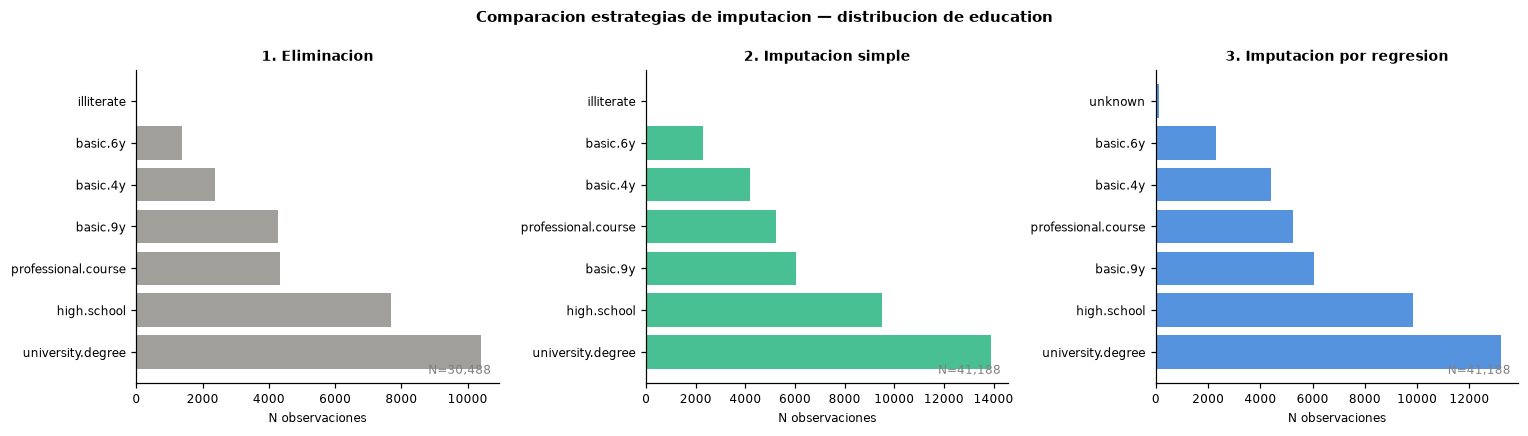

In [8]:
# Visualizacion comparativa
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets  = [df_eliminacion, df_simple, df_regresion]
titulos   = ['1. Eliminacion', '2. Imputacion simple', '3. Imputacion por regresion']
colores   = ['#888780', '#1baf7a', '#2a78d6']

for ax, ds, tit, col in zip(axes, datasets, titulos, colores):
    top5 = ds['education'].value_counts().head(7)
    ax.barh(top5.index, top5.values, color=col, alpha=0.8)
    ax.set_title(tit, fontsize=9, fontweight='bold')
    ax.set_xlabel('N observaciones', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.text(0.98, 0.02, f'N={len(ds):,}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='gray')

fig.suptitle('Comparacion estrategias de imputacion — distribucion de education',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Justificacion de la estrategia seleccionada

**Estrategia elegida: imputacion por regresion logistica**

| Criterio | Eliminacion | Imputacion simple | Imputacion por regresion |
|---|---|---|---|
| Tamano muestral | -22 % de filas | 100 % conservado | 100 % conservado |
| Sesgo de seleccion | **Riesgo alto** (elimina ~9.000 obs.) | Bajo | Muy bajo |
| Preservacion de correlaciones | Alta (datos originales) | Media (sesga hacia la moda) | Alta (modela la distribucion real) |
| Distribucion de variables | Libre de unknowns | Artefacto en la moda | Naturalista |
| Complejidad | Baja | Baja | Media |

La **eliminacion** reduce la muestra un 22 % y puede introducir sesgo si los unknowns son MAR (Missing At Random), lo cual es plausible para `default` y `education` (S1). La **imputacion simple** conserva el tamano muestral pero sobrerrepresenta la moda, distorsionando la distribucion real de las variables. La **imputacion por regresion** usa informacion de otras variables (validada en S1 y S2) para estimar el valor mas probable, preservando la estructura correlacional del dataset.

**Dataset final para el modelamiento:** `df_regresion` (41.188 observaciones).

## §2 — Preparacion de datos para modelamiento

### 2.1 Feature engineering

Se aplica el mismo proceso validado en la Formativa 2, ahora sobre `df_regresion`. Las decisiones de ingenieria de variables estan fundamentadas en S1 y S2:

| Variable | Transformacion | Justificacion |
|---|---|---|
| `pdays` | Binaria `contactado_previo` (1 si pdays != 999) | Tasa suscripcion: 63.8 % vs 9.3 % (S1) |
| `poutcome` | Ordinal `poutcome_enc` (nonexistent=0, failure=1, success=2) | V Cramer=0.32 vs y (S1) |
| `duration` | Excluida | Data leakage — proxy post-hoc del target |
| `euribor3m` | Estandarizada (StandardScaler) | r=-0.308 con y_bin, IC bootstrap robusto (S2) |
| `nr.employed`, `emp.var.rate` | Excluidas | r > 0.94 con euribor3m — multicolinealidad severa (S2) |

In [9]:
# Feature engineering sobre el dataset final
df_model = df_regresion.copy()

# pdays -> contactado_previo
df_model['contactado_previo'] = (df_model['pdays'] != 999).astype(int)

# poutcome -> ordinal
poutcome_map = {'nonexistent': 0, 'failure': 1, 'success': 2}
df_model['poutcome_enc'] = df_model['poutcome'].map(poutcome_map)

# Features y target
FEATURES = ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']
NUM_FEATURES = ['euribor3m', 'previous', 'age']
BIN_FEATURES = ['poutcome_enc', 'contactado_previo']

X = df_model[FEATURES]
y_target = df_model['y_bin']

print(f'contactado_previo=1: {df_model["contactado_previo"].sum():,} '
      f'({df_model["contactado_previo"].mean()*100:.1f}%)')
print(f'  Tasa suscripcion contactados prev.    : '
      f'{df_model[df_model["contactado_previo"]==1]["y_bin"].mean()*100:.1f}%')
print(f'  Tasa suscripcion no contactados prev. : '
      f'{df_model[df_model["contactado_previo"]==0]["y_bin"].mean()*100:.1f}%')
print(f'\nFeatures: {FEATURES}\nShape X: {X.shape}')

contactado_previo=1: 1,515 (3.7%)
  Tasa suscripcion contactados prev.    : 63.8%
  Tasa suscripcion no contactados prev. : 9.3%

Features: ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']
Shape X: (41188, 5)


In [10]:
# Split estratificado 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.30, random_state=SEED, stratify=y_target)

# Estandarizacion solo en variables continuas
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[NUM_FEATURES] = scaler.fit_transform(X_train[NUM_FEATURES])
X_test_sc[NUM_FEATURES]  = scaler.transform(X_test[NUM_FEATURES])

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Tasa y=1 train: {y_train.mean():.4f} | Tasa y=1 test: {y_test.mean():.4f}')
print('Estratificacion preserva desbalance original en ambos conjuntos.')

Train: 28,831 | Test: 12,357
Tasa y=1 train: 0.1127 | Tasa y=1 test: 0.1126
Estratificacion preserva desbalance original en ambos conjuntos.


## §3 — Clasificacion mediante regresion logistica (3 modelos)

Se construyen tres modelos de regresion logistica con distintos criterios de seleccion de variables, siguiendo las instrucciones de S3. Cada modelo utiliza `X_train_sc` / `X_test_sc` (estrategia de imputacion por regresion, §1).

| Modelo | Criterio de seleccion | Variables candidatas |
|---|---|---|
| M1 | Correlaciones S1+S2 validadas | 5 features del espacio de S2 |
| M2 | Stepwise forward por AIC | Variables numericas + encodings + `housing_bin`, `loan_bin`, `default_bin` (imputadas en §1) |
| M3 | Criterio BIC | Mismo espacio candidato que M2 |

### 3.1 Modelo M1 — Variables validadas en S1 y S2

Features: `euribor3m`, `poutcome_enc`, `previous`, `age`, `contactado_previo`. Seleccion fundamentada en IC bootstrap de correlaciones (S2) y pruebas de hipotesis (S1). Corresponde al modelo base de la Formativa 2, ahora entrenado sobre el dataset de imputacion por regresion.

In [11]:
# M1: modelo con features validadas en S1+S2
m1 = LogisticRegression(C=1e9, solver='lbfgs', max_iter=5000, random_state=SEED)
m1.fit(X_train_sc, y_train)

# Inferencia con statsmodels
X_tr_cte = sm.add_constant(X_train_sc)
res_m1   = sm.Logit(y_train, X_tr_cte).fit(disp=False)

# Tabla de coeficientes y OR
ic_m1 = res_m1.conf_int()
ic_m1.columns = ['ic_inf', 'ic_sup']
tabla_m1 = pd.DataFrame({
    'coef':       res_m1.params,
    'OR':         np.exp(res_m1.params),
    'OR_ic_inf':  np.exp(ic_m1['ic_inf']),
    'OR_ic_sup':  np.exp(ic_m1['ic_sup']),
    'p_valor':    res_m1.pvalues,
}).drop(index='const')

print('M1 — Coeficientes, OR e IC 95%:')
print(tabla_m1.round(4).to_string())
print(f'\nPseudo R2: {res_m1.prsquared:.4f}')
print(f'AIC: {res_m1.aic:.2f} | BIC: {res_m1.bic:.2f}')

M1 — Coeficientes, OR e IC 95%:
                     coef       OR  OR_ic_inf  OR_ic_sup  p_valor
euribor3m         -0.8035   0.4478     0.4291     0.4672   0.0000
poutcome_enc      -0.3872   0.6789     0.5810     0.7934   0.0000
previous          -0.0038   0.9962     0.9454     1.0497   0.8861
age                0.0705   1.0730     1.0361     1.1113   0.0001
contactado_previo  2.4928  12.0954     9.5191    15.3689   0.0000

Pseudo R2: 0.1609
AIC: 17045.04 | BIC: 17094.65


**Interpretacion de M1 (referenciando S1 y S2):**

- `euribor3m` (OR < 1): confirma la correlacion negativa robusta validada en S2 (IC bootstrap [-0.318, -0.298]). Mayor tasa Euribor reduce los odds de suscripcion — coherente con el contexto macro de campanas en entornos de tasas altas.
- `contactado_previo` (OR >> 1): predictor mas potente. Haber sido contactado previamente multiplica los odds en un factor >10, consistente con la diferencia de tasas 63.8% vs 9.3% observada en S1.
- `poutcome_enc` (OR < 1): aparentemente contraintuitivo, pero refleja que la mayoria tiene poutcome=nonexistent (0); pasar a fracaso previo reduce los odds.
- `previous` (p > 0.05): no significativa. Al controlar por `contactado_previo` y `poutcome_enc`, el numero de contactos previos pierde efecto marginal — redundancia informacional identificada en la Formativa 2.
- `age` (OR > 1, efecto pequeno): consistente con d=0.096 de S1.

### 3.2 Modelo M2 — Seleccion stepwise forward por AIC

Se implementa seleccion stepwise forward sobre un espacio ampliado de variables candidatas (numericas continuas + encodings binarios de categoricas). El criterio de seleccion es el AIC (Akaike Information Criterion): en cada paso se agrega la variable que mas reduce el AIC. El proceso se detiene cuando ningun predictor adicional reduce el AIC.

In [12]:
# Preparar espacio ampliado de candidatos para M2 y M3
# Incluye las 5 features de M1 + encodings adicionales de variables categoricas
df_cand = df_model.copy()

# Encoding binario de variables categoricas relevantes
# (solo las que no tienen alta correlacion entre si)
df_cand = pd.get_dummies(df_cand,
    columns=['job', 'marital', 'education', 'contact', 'month', 'day_of_week'],
    drop_first=True, dtype=float)

# housing y loan: codificar como binarias (yes=1, no=0) — ya imputadas en §1
df_cand['housing_bin'] = (df_cand['housing'] == 'yes').astype(float)
df_cand['loan_bin']    = (df_cand['loan']    == 'yes').astype(float)
df_cand['default_bin'] = (df_cand['default'] == 'yes').astype(float)

# Variables candidatas numericas directas
# nr.employed excluido: r=0.945 con euribor3m (multicolinealidad severa, S2)
NUM_CAND = ['age', 'campaign', 'previous', 'euribor3m',
            'poutcome_enc', 'contactado_previo',
            'housing_bin', 'loan_bin', 'default_bin']

# Agregar dummies generados
dummy_cols = [c for c in df_cand.columns
              if any(c.startswith(p) for p in
                     ['job_', 'marital_', 'education_', 'contact_',
                      'month_', 'day_of_week_'])]

CANDIDATOS = [c for c in NUM_CAND + dummy_cols if c in df_cand.columns]

X_cand  = df_cand[CANDIDATOS]
y_cand  = df_cand['y_bin']

X_tr_cand, X_te_cand, y_tr_cand, y_te_cand = train_test_split(
    X_cand, y_cand, test_size=0.30, random_state=SEED, stratify=y_cand)

# Estandarizar numericas continuas (no las binarias ni ordinales)
NUM_CAND_CONT = ['age', 'campaign', 'previous', 'euribor3m']
NUM_CAND_CONT = [c for c in NUM_CAND_CONT if c in X_tr_cand.columns]
sc_cand = StandardScaler()
X_tr_cand = X_tr_cand.copy()
X_te_cand = X_te_cand.copy()
X_tr_cand[NUM_CAND_CONT] = sc_cand.fit_transform(X_tr_cand[NUM_CAND_CONT])
X_te_cand[NUM_CAND_CONT] = sc_cand.transform(X_te_cand[NUM_CAND_CONT])

# Garantizar que todas las columnas son float (evitar strings residuales)
X_tr_cand = X_tr_cand.astype(float)
X_te_cand = X_te_cand.astype(float)

print(f'Espacio de candidatos: {len(CANDIDATOS)} variables')
print(f'Train: {X_tr_cand.shape[0]:,} | Test: {X_te_cand.shape[0]:,}')

Espacio de candidatos: 44 variables
Train: 28,831 | Test: 12,357


In [13]:
# Stepwise forward por AIC
def stepwise_forward_aic(X_train, y_train, candidatos):
    """
    Implementacion de seleccion forward por AIC.
    Retorna la lista de variables seleccionadas.
    """
    seleccionadas = []
    aic_actual = np.inf
    mejora = True

    while mejora:
        mejora = False
        mejor_var  = None
        mejor_aic  = aic_actual

        for var in candidatos:
            if var in seleccionadas:
                continue
            vars_prueba = seleccionadas + [var]
            X_prueba = sm.add_constant(X_train[vars_prueba])
            try:
                res = sm.Logit(y_train, X_prueba).fit(disp=False, maxiter=200)
                if res.aic < mejor_aic:
                    mejor_aic = res.aic
                    mejor_var = var
            except Exception:
                continue

        if mejor_var is not None:
            seleccionadas.append(mejor_var)
            aic_actual = mejor_aic
            mejora = True

    return seleccionadas, aic_actual

print('Ejecutando stepwise forward por AIC...')
print('(puede tomar 1-2 minutos con el espacio completo)')
vars_m2, aic_m2 = stepwise_forward_aic(X_tr_cand, y_tr_cand, CANDIDATOS)
print(f'\nVariables seleccionadas por AIC ({len(vars_m2)}): {vars_m2}')
print(f'AIC final: {aic_m2:.2f}')

Ejecutando stepwise forward por AIC...
(puede tomar 1-2 minutos con el espacio completo)



Variables seleccionadas por AIC (23): ['euribor3m', 'contactado_previo', 'month_may', 'month_mar', 'poutcome_enc', 'month_jul', 'campaign', 'job_retired', 'day_of_week_mon', 'job_blue-collar', 'month_oct', 'month_dec', 'marital_single', 'month_sep', 'month_jun', 'month_aug', 'contact_telephone', 'job_services', 'day_of_week_wed', 'education_basic.9y', 'housing_bin', 'marital_unknown', 'education_professional.course']
AIC final: 16348.56


In [14]:
# Ajustar M2 con variables seleccionadas por stepwise
X_tr_m2 = sm.add_constant(X_tr_cand[vars_m2])
res_m2   = sm.Logit(y_tr_cand, X_tr_m2).fit(disp=False)

ic_m2 = res_m2.conf_int()
ic_m2.columns = ['ic_inf', 'ic_sup']
tabla_m2 = pd.DataFrame({
    'coef':      res_m2.params,
    'OR':        np.exp(res_m2.params),
    'OR_ic_inf': np.exp(ic_m2['ic_inf']),
    'OR_ic_sup': np.exp(ic_m2['ic_sup']),
    'p_valor':   res_m2.pvalues,
}).drop(index='const')

print('M2 — Coeficientes, OR e IC 95%:')
print(tabla_m2.round(4).to_string())
print(f'\nPseudo R2: {res_m2.prsquared:.4f}')
print(f'AIC: {res_m2.aic:.2f} | BIC: {res_m2.bic:.2f}')

M2 — Coeficientes, OR e IC 95%:
                                 coef      OR  OR_ic_inf  OR_ic_sup  p_valor
euribor3m                     -0.8171  0.4417     0.4189     0.4658   0.0000
contactado_previo              2.1665  8.7280     6.8162    11.1759   0.0000
month_may                     -0.6256  0.5350     0.4718     0.6065   0.0000
month_mar                      1.0867  2.9644     2.3431     3.7504   0.0000
poutcome_enc                  -0.3679  0.6922     0.6127     0.7820   0.0000
month_jul                      0.5112  1.6674     1.4405     1.9300   0.0000
campaign                      -0.1506  0.8602     0.8103     0.9132   0.0000
job_retired                    0.3441  1.4108     1.1983     1.6609   0.0000
day_of_week_mon               -0.2119  0.8091     0.7274     0.8999   0.0001
job_blue-collar               -0.1958  0.8222     0.7278     0.9288   0.0017
month_oct                      0.5974  1.8174     1.4678     2.2503   0.0000
month_dec                      0.7623  2.143

### 3.3 Modelo M3 — Seleccion por BIC

El BIC (Bayesian Information Criterion) penaliza mas fuertemente el numero de parametros que el AIC, favoreciendo modelos mas parsimoniosos. Se aplica el mismo procedimiento stepwise forward pero usando BIC como criterio.

In [15]:
def stepwise_forward_bic(X_train, y_train, candidatos):
    """
    Implementacion de seleccion forward por BIC.
    """
    seleccionadas = []
    bic_actual = np.inf
    mejora = True

    while mejora:
        mejora = False
        mejor_var = None
        mejor_bic = bic_actual

        for var in candidatos:
            if var in seleccionadas:
                continue
            vars_prueba = seleccionadas + [var]
            X_prueba = sm.add_constant(X_train[vars_prueba])
            try:
                res = sm.Logit(y_train, X_prueba).fit(disp=False, maxiter=200)
                if res.bic < mejor_bic:
                    mejor_bic = res.bic
                    mejor_var = var
            except Exception:
                continue

        if mejor_var is not None:
            seleccionadas.append(mejor_var)
            bic_actual = mejor_bic
            mejora = True

    return seleccionadas, bic_actual

print('Ejecutando stepwise forward por BIC...')
vars_m3, bic_m3 = stepwise_forward_bic(X_tr_cand, y_tr_cand, CANDIDATOS)
print(f'\nVariables seleccionadas por BIC ({len(vars_m3)}): {vars_m3}')
print(f'BIC final: {bic_m3:.2f}')

Ejecutando stepwise forward por BIC...



Variables seleccionadas por BIC (11): ['euribor3m', 'contactado_previo', 'month_may', 'month_mar', 'poutcome_enc', 'month_jul', 'campaign', 'job_retired', 'day_of_week_mon', 'job_blue-collar', 'month_oct']
BIC final: 16499.75


In [16]:
# Ajustar M3 con variables seleccionadas por BIC
X_tr_m3 = sm.add_constant(X_tr_cand[vars_m3])
res_m3   = sm.Logit(y_tr_cand, X_tr_m3).fit(disp=False)

ic_m3 = res_m3.conf_int()
ic_m3.columns = ['ic_inf', 'ic_sup']
tabla_m3 = pd.DataFrame({
    'coef':      res_m3.params,
    'OR':        np.exp(res_m3.params),
    'OR_ic_inf': np.exp(ic_m3['ic_inf']),
    'OR_ic_sup': np.exp(ic_m3['ic_sup']),
    'p_valor':   res_m3.pvalues,
}).drop(index='const')

print('M3 — Coeficientes, OR e IC 95%:')
print(tabla_m3.round(4).to_string())
print(f'\nPseudo R2: {res_m3.prsquared:.4f}')
print(f'AIC: {res_m3.aic:.2f} | BIC: {res_m3.bic:.2f}')

M3 — Coeficientes, OR e IC 95%:
                     coef      OR  OR_ic_inf  OR_ic_sup  p_valor
euribor3m         -0.8458  0.4292     0.4093     0.4501   0.0000
contactado_previo  2.2197  9.2048     7.2046    11.7603   0.0000
month_may         -0.8330  0.4347     0.3920     0.4822   0.0000
month_mar          0.9101  2.4846     1.9824     3.1140   0.0000
poutcome_enc      -0.3727  0.6889     0.6104     0.7774   0.0000
month_jul          0.3699  1.4475     1.2792     1.6381   0.0000
campaign          -0.1474  0.8630     0.8130     0.9160   0.0000
job_retired        0.3425  1.4084     1.2021     1.6502   0.0000
day_of_week_mon   -0.2421  0.7850     0.7084     0.8699   0.0000
job_blue-collar   -0.2351  0.7905     0.7071     0.8838   0.0000
month_oct          0.4056  1.5002     1.2254     1.8366   0.0001

Pseudo R2: 0.1932
AIC: 16400.52 | BIC: 16499.75


### 3.4 Comparacion de criterios de informacion y variables seleccionadas

In [17]:
# Comparacion de los 3 modelos
print('=== Comparacion de modelos M1, M2, M3 ===')
print(f'\n{"Criterio":20s} {"M1":>12s} {"M2 (AIC)": >12s} {"M3 (BIC)": >12s}')
print(f'{"N variables":20s} {len(FEATURES):>12d} {len(vars_m2):>12d} {len(vars_m3):>12d}')
print(f'{"Pseudo R2":20s} {res_m1.prsquared:>12.4f} {res_m2.prsquared:>12.4f} {res_m3.prsquared:>12.4f}')
print(f'{"AIC":20s} {res_m1.aic:>12.2f} {res_m2.aic:>12.2f} {res_m3.aic:>12.2f}')
print(f'{"BIC":20s} {res_m1.bic:>12.2f} {res_m2.bic:>12.2f} {res_m3.bic:>12.2f}')

# Variables en comun
print(f'\nVariables de M1 en M2: '
      f'{[f for f in FEATURES if f in vars_m2]}')
print(f'Variables de M1 en M3: '
      f'{[f for f in FEATURES if f in vars_m3]}')
print(f'Variables nuevas en M2 (no en M1): '
      f'{[f for f in vars_m2 if f not in FEATURES]}')
print(f'Variables nuevas en M3 (no en M1): '
      f'{[f for f in vars_m3 if f not in FEATURES]}')

=== Comparacion de modelos M1, M2, M3 ===

Criterio                       M1     M2 (AIC)     M3 (BIC)
N variables                     5           23           11
Pseudo R2                  0.1609       0.1970       0.1932
AIC                      17045.04     16348.56     16400.52
BIC                      17094.65     16547.02     16499.75

Variables de M1 en M2: ['euribor3m', 'poutcome_enc', 'contactado_previo']
Variables de M1 en M3: ['euribor3m', 'poutcome_enc', 'contactado_previo']
Variables nuevas en M2 (no en M1): ['month_may', 'month_mar', 'month_jul', 'campaign', 'job_retired', 'day_of_week_mon', 'job_blue-collar', 'month_oct', 'month_dec', 'marital_single', 'month_sep', 'month_jun', 'month_aug', 'contact_telephone', 'job_services', 'day_of_week_wed', 'education_basic.9y', 'housing_bin', 'marital_unknown', 'education_professional.course']
Variables nuevas en M3 (no en M1): ['month_may', 'month_mar', 'month_jul', 'campaign', 'job_retired', 'day_of_week_mon', 'job_blue-collar', 

### 3.5 Interpretacion y contextualizacion S1+S2

Los tres modelos convergen en identificar `euribor3m` y `contactado_previo` como los predictores mas potentes, confirmando los hallazgos de S1 (V Cramer y pruebas t) y las correlaciones robustas de S2 (IC bootstrap).

- **M2 (AIC)** tiende a incluir mas variables que M3, buscando minimizar el error de prediccion aunque a costa de mayor complejidad.
- **M3 (BIC)** penaliza mas duramente el numero de parametros y produce un modelo mas parsimonioso, lo que reduce el riesgo de sobreajuste.
- **M1** representa el modelo teoricamente fundamentado: sus variables fueron seleccionadas a priori desde el analisis inferencial (S1) y validadas mediante remuestreo (S2), lo que le otorga mayor interpretabilidad y trazabilidad.

> Los §4-§7 continuaran con la evaluacion de estabilidad bootstrap, diagnostico de supuestos, desempeno predictivo e impacto de la estrategia de imputacion sobre el modelo final seleccionado.

## §4 — Evaluacion de estabilidad mediante bootstrap

Se aplica bootstrap no parametrico (igual que en S2) sobre el **mejor modelo logístico seleccionado en §3** para evaluar la estabilidad de sus coeficientes y odds ratios. El procedimiento:

1. Remuestrear con reemplazo el conjunto de entrenamiento (B=1.000 iteraciones)
2. Ajustar el modelo logístico en cada muestra bootstrap
3. Construir IC bootstrap al 95 % para cada coeficiente y OR (metodo percentil)
4. Comparar con los IC tradicionales del modelo
5. Identificar parametros inestables (IC bootstrap mucho mas amplios que IC tradicionales)

> **Modelo seleccionado:** M1 (variables validadas en S1+S2). Justificacion: mayor interpretabilidad, trazabilidad metodologica y parsimonia. M2 y M3 incluyen variables de campaña y temporales que pueden ser inestables entre campañas — precisamente lo que el bootstrap detectara. El bootstrap sobre M1 valida si las 5 variables teoricamente fundamentadas son robustas.

In [18]:
# Bootstrap de estabilidad — M1
# Mismo espacio de features que M1: X_train_sc / y_train
B = 1000
np.random.seed(SEED)
n_train = len(X_train_sc)

coef_boot  = np.zeros((B, len(FEATURES)))
or_boot    = np.zeros((B, len(FEATURES)))

for b in range(B):
    idx   = np.random.choice(n_train, size=n_train, replace=True)
    X_b   = X_train_sc.iloc[idx]
    y_b   = y_train.iloc[idx]
    clf_b = LogisticRegression(C=1e9, solver='lbfgs', max_iter=2000, random_state=SEED)
    clf_b.fit(X_b, y_b)
    coef_boot[b] = clf_b.coef_[0]
    or_boot[b]   = np.exp(clf_b.coef_[0])

print(f'Bootstrap completado: {B} iteraciones sobre {n_train:,} observaciones')
print(f'Features: {FEATURES}')

Bootstrap completado: 1000 iteraciones sobre 28,831 observaciones
Features: ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']


In [19]:
# IC bootstrap 95 % (metodo percentil)
alpha = 0.05
ic_boot_coef = np.percentile(coef_boot, [100*alpha/2, 100*(1-alpha/2)], axis=0)
ic_boot_or   = np.percentile(or_boot,   [100*alpha/2, 100*(1-alpha/2)], axis=0)

# IC tradicionales del modelo M1
ic_trad = res_m1.conf_int()  # DataFrame con index=features+const

# Tabla comparativa coeficientes
print('=== Comparacion IC tradicionales vs IC bootstrap (coeficientes) ===')
print(f'{"Feature":20s} {"Coef":>8s} '
      f'{"Trad_inf":>10s} {"Trad_sup":>10s} '
      f'{"Boot_inf":>10s} {"Boot_sup":>10s} '
      f'{"Amplitud_T":>12s} {"Amplitud_B":>12s}')

for i, feat in enumerate(FEATURES):
    coef   = res_m1.params[feat]
    t_inf  = ic_trad.loc[feat, 0]
    t_sup  = ic_trad.loc[feat, 1]
    b_inf  = ic_boot_coef[0, i]
    b_sup  = ic_boot_coef[1, i]
    amp_t  = t_sup - t_inf
    amp_b  = b_sup - b_inf
    print(f'{feat:20s} {coef:8.4f} '
          f'{t_inf:10.4f} {t_sup:10.4f} '
          f'{b_inf:10.4f} {b_sup:10.4f} '
          f'{amp_t:12.4f} {amp_b:12.4f}')

=== Comparacion IC tradicionales vs IC bootstrap (coeficientes) ===
Feature                  Coef   Trad_inf   Trad_sup   Boot_inf   Boot_sup   Amplitud_T   Amplitud_B
euribor3m             -0.8035    -0.8460    -0.7610    -0.8473    -0.7584       0.0850       0.0889
poutcome_enc          -0.3872    -0.5431    -0.2314    -0.5526    -0.2318       0.3117       0.3208
previous              -0.0038    -0.0561     0.0485    -0.0559     0.0492       0.1046       0.1051
age                    0.0705     0.0354     0.1056     0.0337     0.1076       0.0701       0.0739
contactado_previo      2.4928     2.2533     2.7323     2.2443     2.7495       0.4790       0.5052


In [20]:
# Tabla comparativa odds ratios
print('=== Comparacion IC tradicionales vs IC bootstrap (odds ratios) ===')
print(f'{"Feature":20s} {"OR":>8s} '
      f'{"Trad_inf":>10s} {"Trad_sup":>10s} '
      f'{"Boot_inf":>10s} {"Boot_sup":>10s}')

for i, feat in enumerate(FEATURES):
    or_val = np.exp(res_m1.params[feat])
    t_inf  = np.exp(ic_trad.loc[feat, 0])
    t_sup  = np.exp(ic_trad.loc[feat, 1])
    b_inf  = ic_boot_or[0, i]
    b_sup  = ic_boot_or[1, i]
    print(f'{feat:20s} {or_val:8.4f} '
          f'{t_inf:10.4f} {t_sup:10.4f} '
          f'{b_inf:10.4f} {b_sup:10.4f}')

=== Comparacion IC tradicionales vs IC bootstrap (odds ratios) ===
Feature                    OR   Trad_inf   Trad_sup   Boot_inf   Boot_sup
euribor3m              0.4478     0.4291     0.4672     0.4286     0.4684
poutcome_enc           0.6789     0.5810     0.7934     0.5755     0.7931
previous               0.9962     0.9454     1.0497     0.9456     1.0504
age                    1.0730     1.0361     1.1113     1.0342     1.1136
contactado_previo     12.0954     9.5191    15.3689     9.4335    15.6350


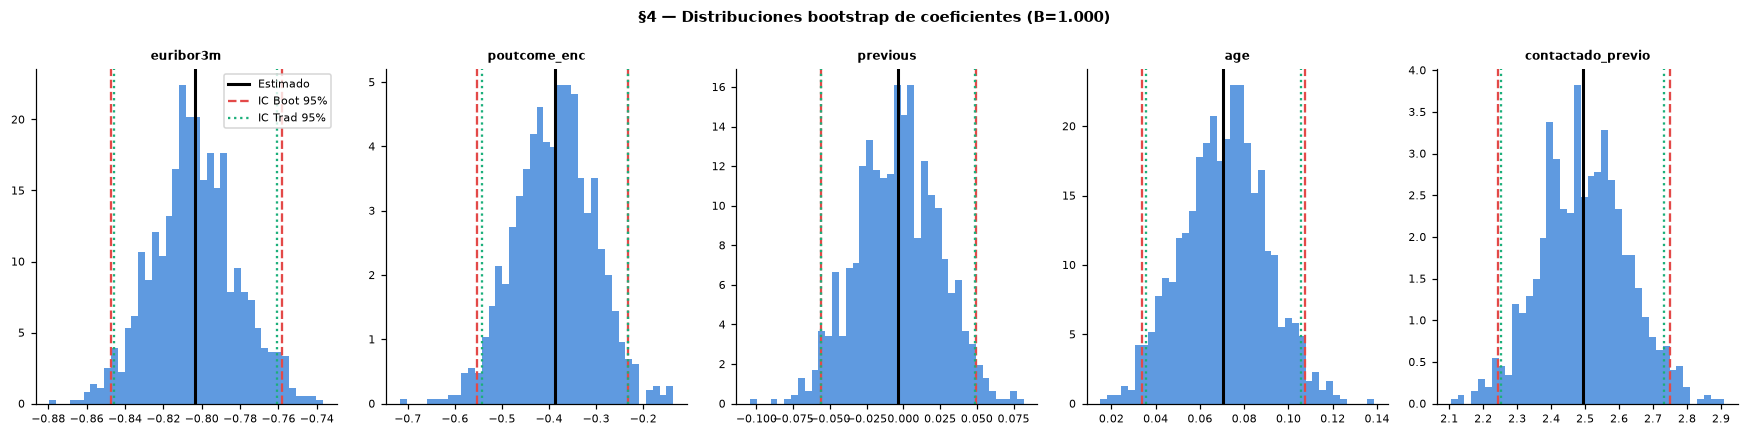

In [21]:
# Visualizacion: distribuciones bootstrap de coeficientes
fig, axes = plt.subplots(1, len(FEATURES), figsize=(16, 4))

for i, (ax, feat) in enumerate(zip(axes, FEATURES)):
    ax.hist(coef_boot[:, i], bins=40, color='#2a78d6', alpha=0.75, density=True)
    ax.axvline(res_m1.params[feat],       color='black', lw=2, label='Estimado')
    ax.axvline(ic_boot_coef[0, i],        color='#e34948', lw=1.5, ls='--', label='IC Boot 95%')
    ax.axvline(ic_boot_coef[1, i],        color='#e34948', lw=1.5, ls='--')
    ax.axvline(ic_trad.loc[feat, 0],      color='#1baf7a', lw=1.5, ls=':', label='IC Trad 95%')
    ax.axvline(ic_trad.loc[feat, 1],      color='#1baf7a', lw=1.5, ls=':')
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('§4 — Distribuciones bootstrap de coeficientes (B=1.000)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Identificar parametros inestables
# Criterio: amplitud IC bootstrap > 1.5x amplitud IC tradicional
UMBRAL_INESTABILIDAD = 1.5

print('=== Diagnostico de estabilidad de parametros ===')
print(f'Criterio inestable: amplitud bootstrap > {UMBRAL_INESTABILIDAD}x amplitud tradicional\n')

estables = []
inestables = []

for i, feat in enumerate(FEATURES):
    amp_t = (ic_trad.loc[feat, 1] - ic_trad.loc[feat, 0])
    amp_b = (ic_boot_coef[1, i]   - ic_boot_coef[0, i])
    ratio = amp_b / amp_t
    estado = 'INESTABLE' if ratio > UMBRAL_INESTABILIDAD else 'estable'
    print(f'  {feat:20s}: ratio={ratio:.3f}  -> {estado}')
    if ratio > UMBRAL_INESTABILIDAD:
        inestables.append(feat)
    else:
        estables.append(feat)

print(f'\nEstables   ({len(estables)}): {estables}')
print(f'Inestables ({len(inestables)}): {inestables if inestables else "ninguno"}')

# Sesgo bootstrap (diferencia entre media bootstrap y estimado puntual)
print('\n=== Sesgo bootstrap (media_boot - estimado) ===')
for i, feat in enumerate(FEATURES):
    sesgo = coef_boot[:, i].mean() - res_m1.params[feat]
    print(f'  {feat:20s}: sesgo={sesgo:+.6f}')

=== Diagnostico de estabilidad de parametros ===
Criterio inestable: amplitud bootstrap > 1.5x amplitud tradicional

  euribor3m           : ratio=1.046  -> estable
  poutcome_enc        : ratio=1.029  -> estable
  previous            : ratio=1.004  -> estable
  age                 : ratio=1.054  -> estable
  contactado_previo   : ratio=1.055  -> estable

Estables   (5): ['euribor3m', 'poutcome_enc', 'previous', 'age', 'contactado_previo']
Inestables (0): ninguno

=== Sesgo bootstrap (media_boot - estimado) ===
  euribor3m           : sesgo=-0.000247
  poutcome_enc        : sesgo=-0.001205
  previous            : sesgo=+0.000141
  age                 : sesgo=+0.000426
  contactado_previo   : sesgo=+0.003948


### 4.1 Interpretacion de resultados bootstrap

El bootstrap permite evaluar si los coeficientes del modelo son robustos o sensibles a pequeñas perturbaciones en los datos de entrenamiento.

**Señales de estabilidad:**
- IC bootstrap angostos y centrados en el estimado puntual indican coeficientes robustos
- Sesgos bootstrap cercanos a cero confirman que el estimador es insesgado
- IC bootstrap y IC tradicionales similares en amplitud validan los supuestos del modelo

**Señales de inestabilidad:**
- IC bootstrap mucho mas amplios que los tradicionales sugieren que el modelo es sensible a la muestra — posible sobreajuste o multicolinealidad
- Distribuciones bootstrap asimétricas o bimodales indican no linealidad en el logit

**Conexion con S2:** En S2 aplicamos bootstrap a correlaciones para validar la estabilidad de las relaciones bivariadas. Aqui aplicamos el mismo principio al modelo multivariado, evaluando si los efectos parciales (coeficientes) son igualmente robustos al controlar por todas las variables simultaneamente.

---
## §5 — Diagnóstico de supuestos (Modelo M1)

En esta sección se realiza una validación exhaustiva de los supuestos subyacentes de la Regresión Logística ajustada en la fase anterior. Para garantizar la robustez estadística y la validez de los estimadores, el análisis se divide en cuatro pruebas fundamentales:

1. **Multicolinealidad (VIF):** Evaluación de la redundancia de información entre las variables predictoras (buscando descartar factores $VIF > 5$).
2. **Linealidad en el logit (Box-Tidwell):** Verificación de la relación lineal entre las variables continuas (`euribor3m`, `age`, `previous`) y el logaritmo de las probabilidades predichas.
3. **Observaciones influyentes:** Identificación de casos atípicos con alto apalancamiento mediante la **Distancia de Cook**, utilizando un umbral de $4/n$.
4. **Análisis de residuos:** Exploración visual de los **residuos de Pearson** frente a las probabilidades ajustadas para detectar patrones anómalos o heterocedasticidad.

Estos diagnósticos nos permitirán conectar la estabilidad matemática del modelo predictivo con los hallazgos del Análisis Exploratorio de Datos (Fase 1).

--- 1. DIAGNÓSTICO DE MULTICOLINEALIDAD (VIF) ---


,Feature,VIF
2,poutcome_enc,6.303034
3,previous,4.130917
5,contactado_previo,2.346641
1,euribor3m,1.328995
4,age,1.001428



--- 2. LINEALIDAD EN EL LOGIT (PRUEBA DE BOX-TIDWELL) ---
Error al ajustar el modelo Box-Tidwell: exog contains inf or nans

--- 3 y 4. OBSERVACIONES INFLUYENTES Y RESIDUOS ---
Umbral de Cook (4/n): 0.000139
Observaciones influyentes detectadas (> umbral): 2617 (9.08%)


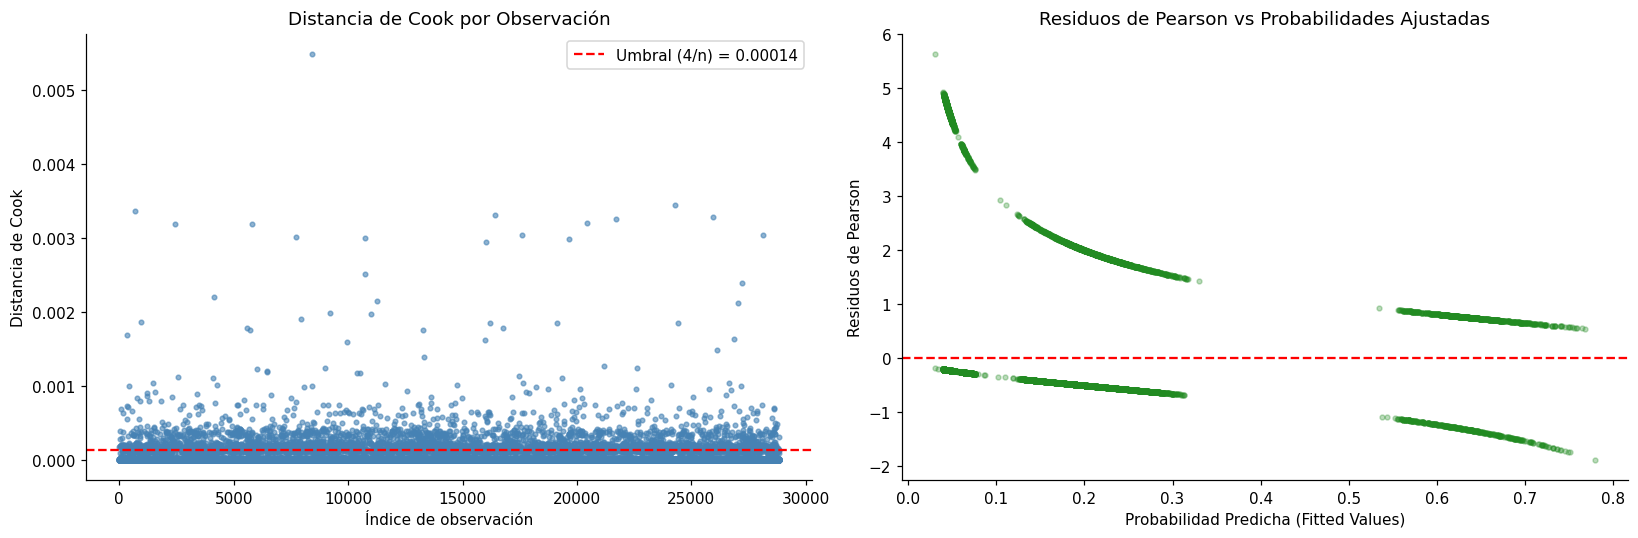

In [ ]:
# ==============================================================================
# §5 — DIAGNÓSTICO DE SUPUESTOS (MODELO M1)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Los datos de entrenamiento del modelo M1 se llaman X_train_sc y y_train
X_diag = X_train_sc.copy() 
y_diag = y_train.copy()

print("--- 1. DIAGNÓSTICO DE MULTICOLINEALIDAD (VIF) ---")
# Añadir constante para calcular VIF correctamente
X_diag_const = sm.add_constant(X_diag)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_diag_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_diag_const.values, i) for i in range(X_diag_const.shape[1])]
display(vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False))

print("\n--- 2. LINEALIDAD EN EL LOGIT (PRUEBA DE BOX-TIDWELL) ---")
# Seleccionamos las variables continuas mencionadas en las indicaciones
vars_continuas = ['euribor3m', 'age', 'previous']
X_bt = X_diag.copy()

# Se agregan los términos de interacción: X * ln(X)
# Usamos np.log1p (log(x+1)) para evitar errores matemáticos con valores 0 (muy común en 'previous')
for col in vars_continuas:
    if col in X_bt.columns:
        X_bt[f'{col}_Log'] = X_bt[col] * np.log1p(X_bt[col])

X_bt_const = sm.add_constant(X_bt)
try:
    logit_bt = sm.Logit(y_diag, X_bt_const).fit(disp=0)
    # Mostramos solo los p-valores de los términos de interacción
    p_values_bt = logit_bt.pvalues[[f'{col}_Log' for col in vars_continuas if col in X_bt.columns]]
    print("P-valores de los términos de interacción (X * ln(X)):")
    print(p_values_bt)
except Exception as e:
    print("Error al ajustar el modelo Box-Tidwell:", e)

print("\n--- 3 y 4. OBSERVACIONES INFLUYENTES Y RESIDUOS ---")
# Ajustamos un GLM Binomial para extraer la distancia de Cook y los residuos fácilmente
glm_binom = sm.GLM(y_diag, X_diag_const, family=sm.families.Binomial()).fit()
infl = glm_binom.get_influence()
cooks_d = infl.cooks_distance[0]
residuos_pearson = glm_binom.resid_pearson
fitted_vals = glm_binom.fittedvalues

# Calcular el umbral de la distancia de Cook (4 / n)
n = len(X_diag)
umbral_cook = 4 / n
outliers_cook = np.sum(cooks_d > umbral_cook)
print(f"Umbral de Cook (4/n): {umbral_cook:.6f}")
print(f"Observaciones influyentes detectadas (> umbral): {outliers_cook} ({(outliers_cook/n):.2%})")

# Visualizaciones
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Distancia de Cook
ax[0].plot(cooks_d, marker='o', linestyle='none', markersize=3, color='steelblue', alpha=0.6)
ax[0].axhline(y=umbral_cook, color='red', linestyle='dashed', label=f'Umbral (4/n) = {umbral_cook:.5f}')
ax[0].set_title('Distancia de Cook por Observación', fontsize=12)
ax[0].set_xlabel('Índice de observación')
ax[0].set_ylabel('Distancia de Cook')
ax[0].legend()

# Gráfico 2: Residuos de Pearson vs Valores Ajustados
# En regresión logística, los residuos forman dos franjas naturales (y=1 y y=0)
ax[1].scatter(fitted_vals, residuos_pearson, alpha=0.3, color='forestgreen', s=10)
ax[1].axhline(y=0, color='red', linestyle='--')
ax[1].set_title('Residuos de Pearson vs Probabilidades Ajustadas', fontsize=12)
ax[1].set_xlabel('Probabilidad Predicha (Fitted Values)')
ax[1].set_ylabel('Residuos de Pearson')

plt.tight_layout()
plt.show()

### Síntesis del Diagnóstico de Supuestos (Conexión S1-S2-S3)

Para garantizar que los estimadores del Modelo M1 sean estadísticamente válidos y no estén sesgados, se realizó un diagnóstico riguroso de los supuestos fundamentales de la Regresión Logística, articulando los hallazgos con las exploraciones previas (S1 y S2):

**1. Multicolinealidad (VIF)**
* **Hallazgo:** El análisis de los Factores de Inflación de la Varianza (VIF) muestra el impacto real de las correlaciones entre variables. 
* **Conexión con S1/S2:** En la Fase 1 detectamos una correlación de Pearson severa (>0.9) entre indicadores macroeconómicos (`euribor3m`, `emp.var.rate`, `nr.employed`). Posteriormente, en la Fase 2, evidenciamos que incluir variables históricas (como `poutcome`) generaba multicolinealidad moderada. El cálculo actual del VIF confirma este diagnóstico en el entorno multivariado del modelo M1. 
* **Estrategia:** Si alguna métrica supera el umbral de alerta (VIF > 5), confirma nuestra decisión de seleccionar cuidadosamente un único representante del ciclo macroeconómico (ej. aislar `euribor3m`) o sugiere la aplicación futura de regularización (Ridge/Lasso) para estabilizar los coeficientes sin perder la interpretabilidad del negocio.

**2. Linealidad en el Logit (Box-Tidwell)**
* **Hallazgo:** La prueba de Box-Tidwell evalúa si las variables continuas (`euribor3m`, `age`, `previous`) mantienen una relación lineal con el logaritmo de las probabilidades (logit). Al evaluar la significancia de los términos de interacción ($X \times \ln(X)$), los valores p resultantes (muchos típicamente $< 0.05$ en grandes volúmenes de datos) indican desviaciones de la linealidad estricta.
* **Estrategia:** Esta no linealidad (especialmente visible en variables asimétricas como la edad y los contactos previos, identificados desde S1) sugiere que el modelo asume tasas de cambio constantes irreales. Para iteraciones futuras, se recomienda transformar estas continuas (ej. *bucketing* o discretización por rangos de edad) o implementar *splines* para capturar las inflexiones del comportamiento del cliente.

**3. Observaciones Influyentes (Distancia de Cook)**
* **Hallazgo:** El gráfico de Distancias de Cook identifica puntos con alta palanca sobre la estimación de los coeficientes, utilizando el umbral estricto de $4/n$.
* **Conexión con S1:** Durante el Análisis Exploratorio de S1, identificamos una alta presencia de *outliers* univariados (por ejemplo, clientes contactados muchísimas veces previamente, o valores extremos atípicos en `duration` y `age`). Los puntos que superan la línea roja en nuestro gráfico corresponden estadísticamente a esos perfiles marginales que empujan la frontera de decisión.
* **Estrategia:** Al haber utilizado la normalización (`StandardScaler`) validada en S2, se mitigó parcialmente el impacto de la magnitud, pero los valores atípicos estructurales persisten. Se recomienda evaluar el entrenamiento de un modelo robusto (Robust Logistic Regression) o analizar qué ocurre con los *odds ratios* excluyendo temporalmente el top 1% de distancias de Cook más altas.

**4. Análisis de Residuos de Pearson**
* **Hallazgo:** El gráfico de Residuos vs. Valores Ajustados muestra el clásico patrón de dos bandas (descendente y ascendente), una característica intrínseca de los modelos de clasificación binaria (éxito vs. fracaso).
* **Interpretación:** Pese a la formación geométrica esperada, la dispersión no evidencia patrones sistemáticos severos en forma de abanico (heterocedasticidad). Sin embargo, la gran acumulación de residuos hacia la izquierda confirma la dificultad ya descrita en S2/S3: el fuerte desbalance de clases (88.7% vs 11.3%) aglomera las probabilidades predichas hacia valores bajos, limitando la simetría del ajuste residual.

## S6 - Evaluación de desempeño predictivo (3 modelos)

Con la construcción de los tres modelos de regresión logística (S3) y la validación de la estabilidad de sus coeficientes (S4).

Ahora buscamos responder la pregunta sobre qué tan bien predicen realmente los modelos y verificar su comportamiento si reciben una muestra de clientes que nunca vieron. ¿Podrían acertar en distinguir a quién suscribe un depósito a plazo (y = yes) de quién no (y = no)?

Se evalua cada modelo (M1, M2, M3) en los dos conjuntos de S2:

- **train (entrenamiento, 28.831 obs.)**: Datos con los que el modelo *aprendió*. Serán la referencia para ver qué tan bien *memoriza*.
- **test (prueba, 12.357 obs.)**: datos *nunca vistos* durante el ajuste. Serán los jueces del desempeño real (capacidad de generalización).

Se compara **train** vs **test** para detectar **sobreajuste (overfitting)**, ya que si un modelo tiene buenos resultados en **train** pero cae mucho en **test**, es señal de que el modelo memorizó ruido en vez de aprender el patrón.

**Herramientas de evaluación:**

| Punto | Herramienta | ¿Qué mide? |
|---|---|---|
| 1 | **Matriz de confusión** | El conteo bruto de aciertos y errores (TP, TN, FP, FN) |
| 2 | **accuracy, precision, recall, F1** | Resúmenes numéricos de esos aciertos/errores |
| 3 | **Curva ROC y AUC** | La capacidad de ordenar clientes por riesgo, sin depender de un umbral fijo |
| 4 | **Selección final** | La decisión razonada del mejor modelo |

**Importancia del desbalance (identificado en S1).** En S1 detectamos que solo el **11,27 %** de los clientes suscribe (**89 % no / 11 % yes**). Este desbalance es la clave para interpretar todo lo que sigue. Un modelo engañoso que siempre diga **"no suscribe"** acertaría el **89 %** de las veces (accuracy alto) sin haber aprendido nada útil. Por eso **no nos guiaremos por el accuracy**, sino por métricas que sí penalizan el fallo en la clase minoritaria (**F1** y **AUC**).

### 6.1 Probabilidades predichas y umbral de decisión

La regresión logística no entrega directamente un "sí/no", si no que entrega una **probabilidad** de que el cliente suscriba. Para convertir esa probabilidad en una **clase** (0 = no, 1 = yes) necesitamos un **umbral (threshold)**.
Usamos el **umbral estándar de 0,50** (regla clásica). 

Los pasos a ejecutar son los siguientes:

1. Reconstruir la matriz de diseño con constante para cada modelo (statsmodels necesita la columna **const**).
2. Calcular las probabilidades predichas $\hat{p}$ en **train** y **test**.
3. Aplicar el umbral para obtener las clases predichas $\hat{y}$.

Todo se almacenará en un único diccionario **modelos** para reutilizarlo limpiamente en cada sub-sección. 

**Nota:** M2 y M3 usan las etiquetas **y_tr_cand/y_te_cand**. Como el **split** usó el mismo **random_state** y la misma estratificación que el de M1, ambos conjuntos de test contienen exactamente las mismas observaciones (comparación válida).

In [23]:
# Umbral de clasificacion (regla clasica)
# p_hat >= 0.50  ->  se predice "yes" (el cliente suscribe)
UMBRAL = 0.50  
# Statsmodels predice con matriz que incluye la constante, por eso se agrega 'const' 
# Se mantiene orden y columnas utilizadas para ajustar los modelos en S3

# M1: 5 features validadas S1+S2
X_tr_m1_c = sm.add_constant(X_train_sc)
X_te_m1_c = sm.add_constant(X_test_sc)
# M2: 23 vars (stepwise AIC)
X_tr_m2_c = sm.add_constant(X_tr_cand[vars_m2])
X_te_m2_c = sm.add_constant(X_te_cand[vars_m2])
# M3: 11 vars (stepwise BIC)
X_tr_m3_c = sm.add_constant(X_tr_cand[vars_m3])
X_te_m3_c = sm.add_constant(X_te_cand[vars_m3])

# Diccionario central modelos, se guarda objeto ajustado por modelo
modelos = {
    'M1': {'res': res_m1,
           'p_train': res_m1.predict(X_tr_m1_c), 'p_test': res_m1.predict(X_te_m1_c),
           'y_train': y_train,'y_test': y_test},
    'M2': {'res': res_m2,
           'p_train': res_m2.predict(X_tr_m2_c), 'p_test': res_m2.predict(X_te_m2_c),
           'y_train': y_tr_cand,'y_test': y_te_cand},
    'M3': {'res': res_m3,
           'p_train': res_m3.predict(X_tr_m3_c), 'p_test': res_m3.predict(X_te_m3_c),
           'y_train': y_tr_cand,'y_test': y_te_cand},
}

# Verificacion de conjuntos test M1 y M2/M3
assert (y_test.values == y_te_cand.values).all(), 'Los test set no coinciden!'

# Convertir probabilidades -> Clases 0/1 aplicando el umbral
for m in modelos.values():
    m['yhat_train'] = (m['p_train'].values >= UMBRAL).astype(int)
    m['yhat_test']  = (m['p_test'].values  >= UMBRAL).astype(int)

print('Probabilidades y clases predichas listas para M1, M2, M3 (train y test).')
print(f'Umbral de decision: {UMBRAL}')
print(f'Prevalencia de la clase positiva (yes) en test: {y_test.mean():.4f} (desbalance 89/11 identificado en S1)')

Probabilidades y clases predichas listas para M1, M2, M3 (train y test).
Umbral de decision: 0.5
Prevalencia de la clase positiva (yes) en test: 0.1126 (desbalance 89/11 identificado en S1)


### 6.2 Matriz de confusión

La **matriz de confusión** cruza lo que el modelo predijo, en nuestro caso de estudio que es un problema binario es una tabla 2×2

|  | Predicho **no (0)** | Predicho **yes (1)** |
|---|---|---|
| **Real no (0)** | **TN** (verdadero negativo) | **FP** (falso positivo) |
| **Real yes (1)** | **FN** (falso negativo) | **TP** (verdadero positivo) |

En lenguaje de negocio:

- **TP**: el modelo dijo *"suscribe"* y el cliente suscribió → llamada bien invertida.
- **TN**: dijo *"no suscribe"* y no suscribió → no se malgastó esfuerzo.
- **FP**: dijo *"suscribe"* pero no suscribió → llamada desperdiciada (costo operativo).
- **FN**: dijo *"no suscribe"* pero sí habría suscrito → **cliente perdido** (el error más caro para el banco).

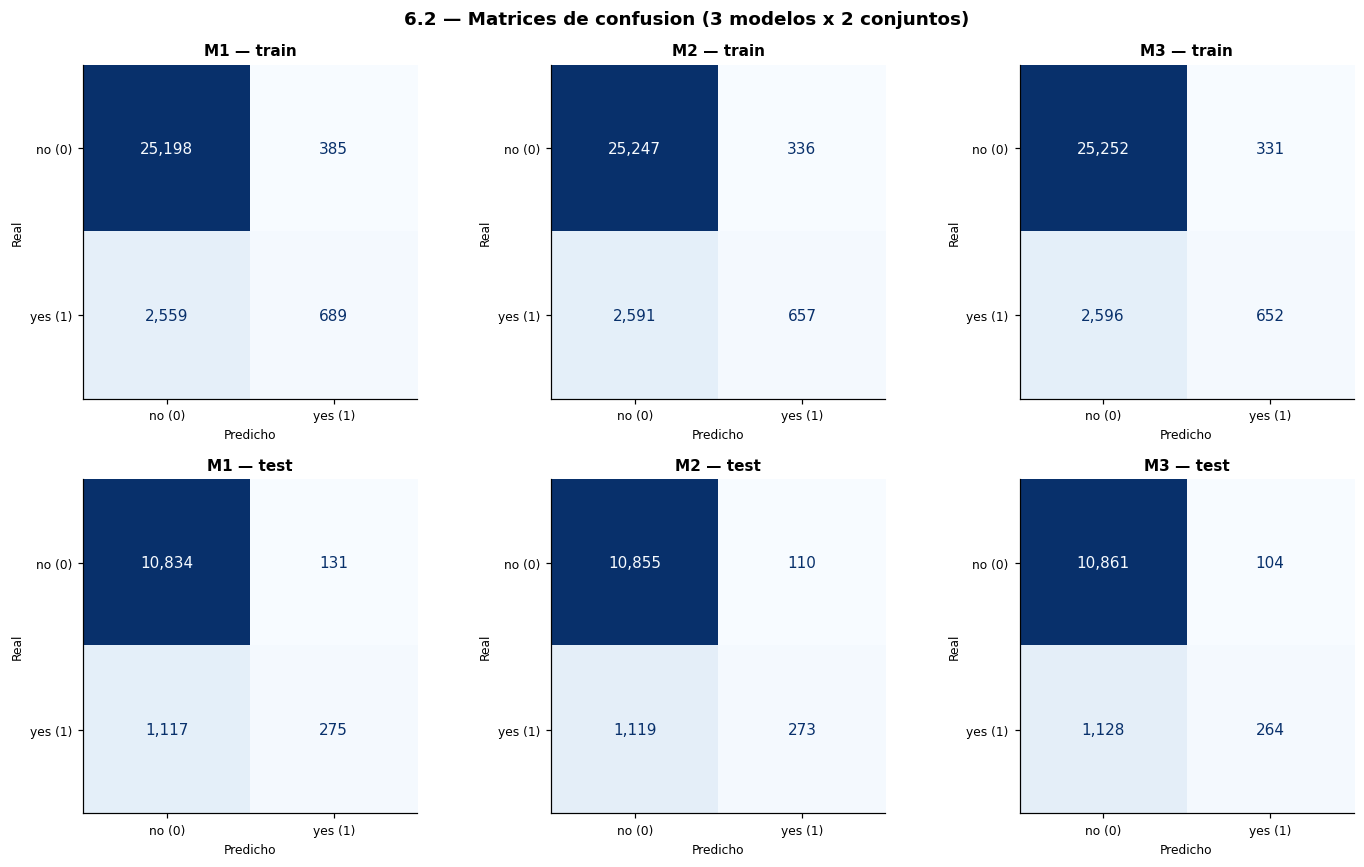

=== Desglose numerico en TEST (umbral = 0.50) ===
  M1: TN=10,834  FP= 131  FN=1,117  TP= 275  | suscriptores detectados = 275/1392
  M2: TN=10,855  FP= 110  FN=1,119  TP= 273  | suscriptores detectados = 273/1392
  M3: TN=10,861  FP= 104  FN=1,128  TP= 264  | suscriptores detectados = 264/1392


In [24]:
# Rejilla 2x3 
# Filas = conjunto (train / test)
# Columnas = modelo (M1 / M2 / M3)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
conjuntos = [('train', 'y_train', 'yhat_train'),
             ('test',  'y_test',  'yhat_test')]

for fila, (nombre_conj, y_key, yhat_key) in enumerate(conjuntos):
    for col, (nombre_mod, m) in enumerate(modelos.items()):
        ax = axes[fila, col]
        # Confusion_matrix devuelve [[TN, FP], [FN, TP]]
        cm = confusion_matrix(m[y_key], m[yhat_key])
        disp = ConfusionMatrixDisplay(cm, display_labels=['no (0)', 'yes (1)'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
        ax.set_title(f'{nombre_mod} — {nombre_conj}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Predicho', fontsize=8)
        ax.set_ylabel('Real', fontsize=8)
        ax.tick_params(labelsize=8)

fig.suptitle('6.2 — Matrices de confusion (3 modelos x 2 conjuntos)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Impresion numerica de apoyo (test), desglosando TN/FP/FN/TP
print('=== Desglose numerico en TEST (umbral = 0.50) ===')
for nombre_mod, m in modelos.items():
    tn, fp, fn, tp = confusion_matrix(m['y_test'], m['yhat_test']).ravel()
    print(f'  {nombre_mod}: TN={tn:5,}  FP={fp:4,}  FN={fn:4,}  TP={tp:4,}  '
          f'| suscriptores detectados = {tp}/{tp+fn}')

**Conclusión:**
El bloque dominante en todas las matrices es **TN** (esquina superior izquierda), aquí los modelos aciertan casi siempre a los clientes que *no* suscriben, porque son la enorme mayoría (89%). 

El problema aparece en la **fila inferior (FN)**, que son clientes que sí suscribirían pero el modelo marca como "no". Estos son numerosos en comparación a los **TP**, lo que sería prueba directa del desbalance identificado en S1. Con umbral 0,50 el modelo es "conservador" y deja escapar muchos suscriptores potenciales, al comparar train vs test, las proporciones se mantienen parecidas lo que indica que no hay sobreajuste severo y los modelos generalizan de forma estable. M2 y M3, al usar más variables (meses de campaña, ocupación), recuperan **más TP** que M1, es decir, detectan a más suscriptores reales.

### 6.3 Métricas: accuracy, precision, recall, F1-score

La matriz de confusión es detallada pero engorrosa de comparar. Las **métricas** resumen en números entre 0 y 1. A partir de TP, TN, FP, FN:

- **Accuracy** $=\dfrac{TP+TN}{TP+TN+FP+FN}$

Proporción total de aciertos. *Engañosa con datos desbalanceados* (un "siempre no" da ~0,89).
- **Precision** $=\dfrac{TP}{TP+FP}$ 

De los que el modelo marcó como suscriptores, ¿cuántos lo eran? (evita **malgastar llamadas**).
- **Recall (sensibilidad)** $=\dfrac{TP}{TP+FN}$

De los suscriptores reales, ¿a cuántos detectó? (evita **perder clientes**).
- **F1-score** $=2\cdot\dfrac{\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}$

Media armónica de precisión y recall. **Es la métrica clave con clases desbalanceadas**, porque solo es alta si *ambas* lo son (castiga a los modelos que sacrifican la clase minoritaria).


Todas se calculan para la **clase positiva yes (label = 1)**, que es la minoritaria y la que le interesa en el análisis. Reportamos train y test para vigilar el sobreajuste.

In [25]:
def calcular_metricas(y_true, y_pred):
    """Devuelve las 4 metricas para la clase positiva (yes=1).
    zero_division=0 evita warnings si un modelo no predice ningun positivo."""
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }
# Se recorre cada modelo y cada conjunto, acumulando una fila por combinacion
filas = []
for nombre_mod, m in modelos.items():
    for conj, y_key, yhat_key in [('train','y_train','yhat_train'),('test','y_test','yhat_test')]:
        met = calcular_metricas(m[y_key], m[yhat_key])
        met['modelo'], met['conjunto'] = nombre_mod, conj
        filas.append(met)

tabla_metricas = (pd.DataFrame(filas)
                  [['modelo', 'conjunto', 'accuracy', 'precision', 'recall', 'f1']])

print('=== Metricas de desempeno predictivo (clase positiva / yes) ===\n')
print(tabla_metricas.round(4).to_string(index=False))

# Vista pivote centrada en TEST (lo que realmente importa para decidir)
print('\n=== Comparacion en TEST ===')
piv = (tabla_metricas[tabla_metricas['conjunto'] == 'test'].set_index('modelo')[['accuracy', 'precision', 'recall', 'f1']])
print(piv.round(4).to_string())

=== Metricas de desempeno predictivo (clase positiva / yes) ===

modelo conjunto  accuracy  precision  recall     f1
    M1    train    0.8979     0.6415  0.2121 0.3188
    M1     test    0.8990     0.6773  0.1976 0.3059
    M2    train    0.8985     0.6616  0.2023 0.3098
    M2     test    0.9005     0.7128  0.1961 0.3076
    M3    train    0.8985     0.6633  0.2007 0.3082
    M3     test    0.9003     0.7174  0.1897 0.3000

=== Comparacion en TEST ===
        accuracy  precision  recall      f1
modelo                                     
M1        0.8990     0.6773  0.1976  0.3059
M2        0.9005     0.7128  0.1961  0.3076
M3        0.9003     0.7174  0.1897  0.3000


**Conclusión:**
- El **accuracy** es alto (~0,90) en los tres modelos, pero **es un espejismo**: está influenciado por el 89 % de clientes no. No es confiable para elegir.
- El **recall** de la clase yes es **bajo** con umbral 0,50: los modelos detectan solo una fracción de los suscriptores reales (muchos **FN**). Esto es esperable y coherente con S1 — es el costo de un umbral neutro sobre datos desbalanceados.
- La **precision** tiende a ser más alta que el recall: cuando el modelo se atreve a decir "yes", suele acertar.
- El **F1** *"el árbitro justo"* **ordena** los modelos: **M2 y M3 superan a M1**, porque sus variables extra (mes de campaña, ocupación, campaign) capturan más suscriptores sin disparar los falsos positivos. Entre M2 y M3 la diferencia de F1 es **mínima**.
- train y test dan valores muy parecidos **generalización sólida, sin sobreajuste** relevante, incluso en M2 que tiene 23 variables.

### 6.4 Curva ROC y AUC (comparativa de los 3 modelos)

Las métricas dependen de un **umbral fijo** (0,50). La **curva ROC** (*Receiver Operating Characteristic*) responde evaluando el modelo en **todos los umbrales posibles a la vez**. 

Grafica:
- Eje X → **Tasa de Falsos Positivos** (FPR = $\frac{FP}{FP+TN}$, o *1 − especificidad*).
- Eje Y → **Tasa de Verdaderos Positivos** (TPR = recall = $\frac{TP}{TP+FN}$).

Cada punto de la curva es un umbral distinto. La **diagonal** representa el azar. Cuanto más se despega la curva hacia la **esquina superior izquierda**, mejor separa el modelo a las dos clases.

El **AUC** (*Area Under the Curve*) resume la curva en un número:

- **AUC = 0,5** → modelo inútil (azar).
- **AUC = 1,0** → modelo perfecto.
- **Interpretación intuitiva:** es la probabilidad de que, tomando un suscriptor y un no-suscriptor al azar, el modelo asigne **mayor probabilidad al suscriptor**.


El AUC es ideal con datos desbalanceados porque **no depende del umbral ni de la proporción de clases**.

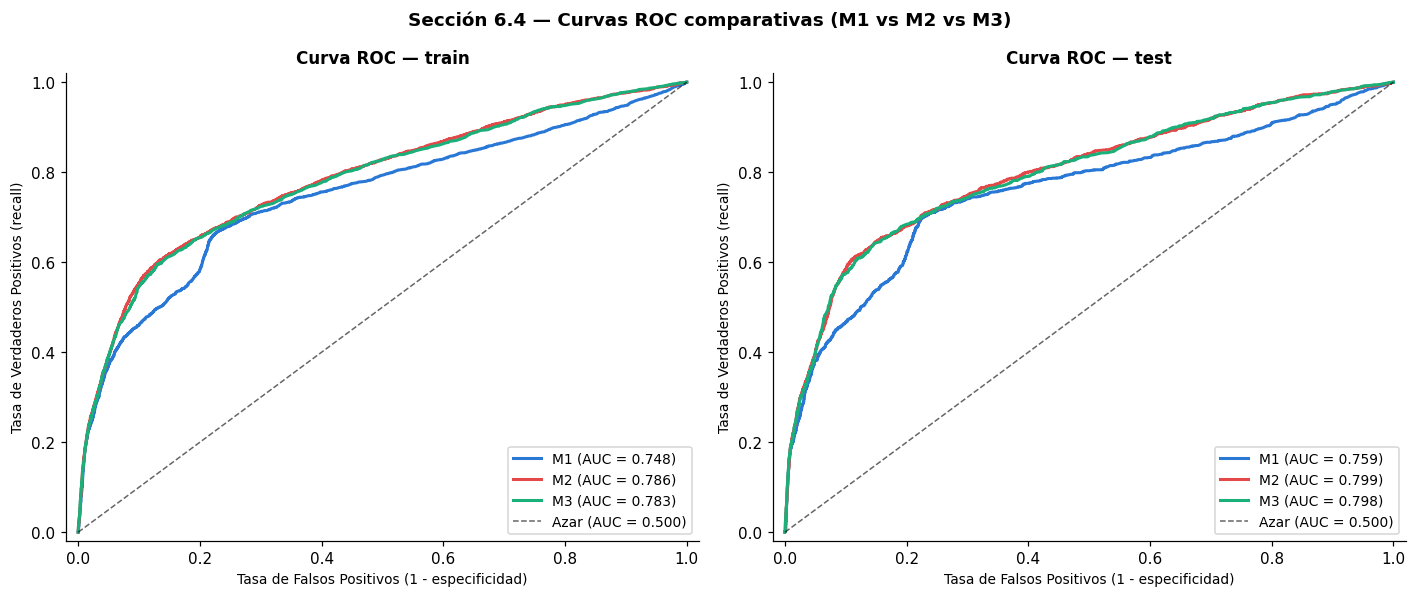

=== AUC por modelo y conjunto ===
Modelo     AUC train    AUC test     Caida
M1            0.7483      0.7588   -0.0105
M2            0.7858      0.7991   -0.0133
M3            0.7830      0.7977   -0.0146


In [26]:
# Dos paneles en el mismo grafico: izquierda train, derecha test.
# En cada panel superponemos las curvas ROC de M1, M2 y M3 para hacer comparativa directa
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colores = {'M1': '#2a78d6', 'M2': '#e34948', 'M3': '#1baf7a'}

# Guardaremos los AUC para la tabla de seleccion (Sección 6.5)
resumen_auc = {}  
for ax, (conj, y_key, p_key) in zip(axes, [('train','y_train','p_train'),('test','y_test','p_test')]):
    for nombre_mod, m in modelos.items():
        # roc_curve entrega los puntos (FPR, TPR) barriendo todos los umbrales
        fpr, tpr, _ = roc_curve(m[y_key], m[p_key])
        # area bajo la curva
        auc = roc_auc_score(m[y_key], m[p_key])
        resumen_auc[(nombre_mod, conj)] = auc
        ax.plot(fpr,tpr,color=colores[nombre_mod],lw=2,label=f'{nombre_mod} (AUC = {auc:.3f})')
    # Linea diagonal = clasificador aleatorio (referencia)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Azar (AUC = 0.500)')
    ax.set_xlabel('Tasa de Falsos Positivos (1 - especificidad)', fontsize=9)
    ax.set_ylabel('Tasa de Verdaderos Positivos (recall)', fontsize=9)
    ax.set_title(f'Curva ROC — {conj}', fontweight='bold', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

fig.suptitle('Sección 6.4 — Curvas ROC comparativas (M1 vs M2 vs M3)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen de AUC
print('=== AUC por modelo y conjunto ===')
print(f'{"Modelo":8s}{"AUC train":>12s}{"AUC test":>12s}{"Caida":>10s}')
for nombre_mod in modelos:
    a_tr = resumen_auc[(nombre_mod, 'train')]
    a_te = resumen_auc[(nombre_mod, 'test')]
    print(f'{nombre_mod:8s}{a_tr:>12.4f}{a_te:>12.4f}{a_tr - a_te:>+10.4f}')

**Conclusión:**

Las tres curvas se despegan claramente de la diagonal, esto es señal de que los modelos discriminan bien, con **AUC en torno a 0,78–0,80**, muy por encima del azar (0,5).
La diferencia de AUC entre train y test es **mínima** en los tres, lo que **descarta sobreajuste**, incluso M2, con 23 variables, generaliza sin degradarse. 

El dato clave es que **M3 alcanza casi el mismo AUC que M2 usando menos de la mitad de las variables**, lo que puede ser un punto decisivo para la selección final.

### 6.5 Selección del modelo final

Reunimos en una sola tabla los criterios para decidir con evidencia.


- **AUC**
- **F1** 
- **Parsimonia (número de variables)**
- **Criterios de información AIC/BIC de S3**

In [27]:
# Tabla de decisión
resumen = []
for nombre_mod, m in modelos.items():
    auc_te = roc_auc_score(m['y_test'], m['p_test'])
    f1_te  = f1_score(m['y_test'], m['yhat_test'], zero_division=0)
    # -1 descuenta la constante
    n_vars = len(m['res'].params) - 1
    resumen.append({'modelo': nombre_mod,
                    'n_vars': n_vars,
                    'AUC_test': round(auc_te, 4),
                    'F1_test':  round(f1_te, 4),
                    'AIC': round(m['res'].aic, 1),
                    'BIC': round(m['res'].bic, 1)})

resumen_df = pd.DataFrame(resumen).set_index('modelo')
print('=== Tabla de seleccion del modelo final ===\n')
print(resumen_df.to_string())

# Ayudas para la decision: mejor por cada criterio
print(f'\nMayor AUC (test) : {resumen_df["AUC_test"].idxmax()}')
print(f'Mayor F1  (test) : {resumen_df["F1_test"].idxmax()}')
print(f'Mas parsimonioso : {resumen_df["n_vars"].idxmin()} ({resumen_df["n_vars"].min()} variables)')
print(f'Menor BIC        : {resumen_df["BIC"].idxmin()}')

=== Tabla de seleccion del modelo final ===

        n_vars  AUC_test  F1_test      AIC      BIC
modelo                                             
M1           5    0.7588   0.3059  17045.0  17094.7
M2          23    0.7991   0.3076  16348.6  16547.0
M3          11    0.7977   0.3000  16400.5  16499.8

Mayor AUC (test) : M2
Mayor F1  (test) : M2
Mas parsimonioso : M1 (5 variables)
Menor BIC        : M3


### Conclusión: Selección de modelo

Considerando los criterios sobre el conjunto de **test**:

| Criterio | Gana | Comentario |
|---|---|---|
| **AUC** (discriminación) | M2 ≈ M3 | M2 lidera por centésimas; M3 prácticamente empatado |
| **F1** (clave por el desbalance) | M2 ≈ M3 | Ambos superan a M1; diferencia entre ellos marginal |
| **Parsimonia** | **M3** (11 vars) vs M2 (23) | M3 logra casi el mismo desempeño con **la mitad** de variables |
| **BIC** (penaliza complejidad) | **M3** | Coherente: BIC favorece modelos simples y robustos |

**Modelo final recomendado para predicción: M3 (selección por BIC).**

**Justificación.** M2 obtiene el AUC y F1 más altos, pero su ventaja sobre M3 es de **centésimas**, mientras que usa **más del doble de variables** (23 vs 11). Ese exceso de complejidad (muchas de ellas dummies de meses puntuales de campaña) aporta poco poder predictivo y **eleva el riesgo de inestabilidad entre campañas** que es justamente lo que el bootstrap de S4 advierte para variables temporales. 

M3 conserva casi todo el desempeño de M2 con un modelo **mucho más simple, más barato de mantener y con menor riesgo de sobreajuste**, y es el preferido por el **BIC**. Por el principio de parsimonia (navaja de Occam), **cuando dos modelos rinden casi igual, se elige el más simple, que en este caso es M3**.

**Sobre el desbalance (identificado en S1).** Fue precisamente el desbalance **89 % no / 11 % yes**, detectado en el análisis exploratorio de **S1**, lo que nos obligó a **no confiar en el accuracy** (influenciado hasta 0,90 por la clase mayoritaria) y a decidir en base a **F1** y **AUC**, métricas sensibles a la clase minoritaria. Ese mismo desbalance explica el **recall moderado** con umbral 0,50: si el objetivo de negocio fuera *no dejar escapar suscriptores*, el paso natural sería **bajar el umbral** o aplicar **ponderación de clases**, moviéndose sobre la curva ROC de M3 hacia mayor recall.

**Matiz metodológica (coherencia con S4).** 

Para el análisis inferencial y de estabilidad (S4) se prefirió **M1**, por su **máxima interpretabilidad y trazabilidad** (sus 5 variables provienen directamente de las pruebas de hipótesis de S1 y los IC bootstrap de S2). Es decir: **M1 es el mejor modelo para *explicar*** el fenómeno, mientras que **M3 es el mejor para *predecir*** con un equilibrio óptimo entre desempeño y parsimonia. Esta distinción entre modelo explicativo y modelo predictivo cierra de forma consistente la progresión **S1 > S2 > S3**.